# Extension: Decoding Analysis Pipeline of Jan Hagnberger and Jianyang Gu

This Jupyter Notebook contains the extension for the course project in "Signal processing and Analysis of human brain potentials (EEG)" at the University of Stuttgart in WS25/26. The goal of this pipeline is to analyze decode the conditions from the data of the paper "[Detecting Visuo-Haptic Mismatches in Virtual Reality using the Prediction Error Negativity of Event-Related Brain Potentials](https://dl.acm.org/doi/10.1145/3290605.3300657)" by Gehrke et al., 2019. We use the data the authors' published on [OpenNeuro (Dataset ds003846)](https://openneuro.org/datasets/ds003846/versions/1.0.1). 


The Jupyter Notebook mainly uses the structure of our main pipeline (`reactiontime_analysis.ipynb`) which is structured as follows:
- **Helper functions**: We define functions for loading the data, preprocessing the EEG signals, and performing the analysis. Each function is documented with a docstring that explains its purpose, inputs, and outputs.
- **Build Pipeline**: Combines all helper functions into a single pipeline that can be easily executed to reproduce the results of the paper. The pipeline includes steps for loading the data, preprocessing it, and creating the epoched data.
- **Run Pipeline**: Executes the pipeline for all subjects and sessions in the dataset, and plots intermediate results if required.
- **Plotting**: Finally, we plot the average of the decoding scores.



In [5]:
import mne
import numpy as np
from matplotlib import pyplot as plt
from mne_bids import BIDSPath, read_raw_bids
import os
import shutil
from joblib import Parallel, delayed
import pandas as pd
from mne.decoding import SlidingEstimator, LinearModel, cross_val_multiscore
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

## Load Helper Functions

In [6]:
from trial_decoding_analysis_functions import remove_problematic_annotations, get_available_sessions, load_data, remove_bad_channels, filtering_referencing, apply_ica_eyes, make_epoched_data, decoding

## Build the Pipeline

In [7]:
def process_subject(bids_root="/Users/jan/Documents/git/ds003846", subject_id="02", show_intermediate_plots=False):
    """Pipeline for processing one subject across all sessions. The pipeline includes loading the data, removing bad
    channels, filtering and re-referencing, applying ICA to remove eye movement artifacts, and finally creating beta
    plots for the condition and reaction time predictors of the GLM analysis. The function returns the raw data to
    plot the final grand-average for all sessions.
    
    Args:
        bids_root: The root path to the BIDS dataset.
        subject_id: The ID of the subject (e.g., "02") as string.
        show_intermediate_plots: Whether to show intermediate plots.
    
    Returns:
        Tuple of
            - Subject ID
            - Beta condition data 
            - Beta centered reaction time data
    """
    
    mne.set_log_level('WARNING')
    
    scores_data = {}
    sessions = get_available_sessions(bids_root=bids_root, subject_id=subject_id)
    print(f"Available sessions for subject {subject_id}: {sessions}")
    
    for session in sessions:
        print(f"Session: {session}")
        # 1. Load data
        data = load_data(bids_root=bids_root, subject_id=subject_id, session=session)
        
        # Plot raw data before and after preprocessing
        if show_intermediate_plots:
            data.plot(start=60, duration=12, n_channels=15)
            data.copy().pick(["Cz"]).compute_psd().plot()
        
        # 2. Remove bad channels manually
        remove_bad_channels(data, int(subject_id))

        # Remove bad events manually
        # We also skip this step for the sake of simplicity and because the results are already good without it.
        
        # 3. Filtering
        data = filtering_referencing(data, show_plots=show_intermediate_plots)
        
        # Plot better data
        if show_intermediate_plots:
            data.plot(start=60, duration=12, n_channels=15)
            data.copy().pick(["Cz"]).compute_psd().plot()
        
        # 4. Apply ICA
        data = apply_ica_eyes(data, show_plots=show_intermediate_plots)
        
        # Plot after ICA
        if show_intermediate_plots:
            data.plot(start=60, duration=12, n_channels=15)
            data.copy().pick(["Cz"]).compute_psd().plot()
        
        # Apply ASR to remove remaining artifacts
        # We skip this step because ASR was extremely slow and the results are also good without it.
        
        # 5. Create epoched data for decoding
        epochs_normal, _ = make_epoched_data(data, condition="normal")
        epochs_conflict, _ = make_epoched_data(data, condition="conflict")
        
        # 6. Decoding
        scores = decoding(epochs_normal, epochs_conflict, show_plots=show_intermediate_plots)
        
        scores_data[session] = scores
        
    return subject_id, scores_data

# Run the Pipeline

In [8]:
# Set the dataset path and subjects here 

DATASET_PATH = "/Users/jan/Documents/git/ds003846"
#subjects = ["02"]
subjects = [f"{i:02d}" for i in range(2, 21) if (i != 3)] # exclude subject 03 because of splitted sessions
print(subjects)
show_intermediate_plots = False

['02', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20']


In [9]:
# Remove the problematic columns from participants.tsv
remove_problematic_annotations(bids_root=DATASET_PATH)

if not show_intermediate_plots:
    # Run the pipeline for each subject in parallel. This is necessary because doing it sequentially takes too much time
    # This only works if we do not want intermediate plots
    output = Parallel(n_jobs=4)(delayed(process_subject)(bids_root=DATASET_PATH, subject_id=subject, show_intermediate_plots=show_intermediate_plots) for subject in subjects)
else:
    # Run the pipeline for each subject sequentially
    # This is needed if we want to show intermediate plots
    output = []
    for subject in subjects:
        result = process_subject(bids_root=DATASET_PATH, subject_id=subject, show_intermediate_plots=show_intermediate_plots)
        output.append(result)

# Store the final results
scores_all = {}

for subject_id, scores in output:
    scores_all[subject_id] = scores

Available sessions for subject 06: ['EMS', 'Visual', 'Vibro']Available sessions for subject 05: ['Visual', 'Vibro']

Session: EMS
Session: Visual
Available sessions for subject 04: ['Visual', 'Vibro']
Session: Visual
Available sessions for subject 02: ['EMS', 'Visual', 'Vibro']
Session: EMS


/Users/jan/Documents/git/eeg/trial_decoding_analysis_functions.py:312: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epochs_all = mne.concatenate_epochs([epochs_normal, epochs_conflict])
/Users/jan/Documents/git/eeg/trial_decoding_analysis_functions.py:312: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epochs_all = mne.concatenate_epochs([epochs_normal, epochs_conflict])


Session: Visual
Session: Visual


/Users/jan/Documents/git/eeg/trial_decoding_analysis_functions.py:312: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epochs_all = mne.concatenate_epochs([epochs_normal, epochs_conflict])
/Users/jan/Documents/git/eeg/trial_decoding_analysis_functions.py:312: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epochs_all = mne.concatenate_epochs([epochs_normal, epochs_conflict])


Session: Vibro
Session: Vibro


...

/Users/jan/Documents/git/eeg/trial_decoding_analysis_functions.py:312: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epochs_all = mne.concatenate_epochs([epochs_normal, epochs_conflict])


Session: Vibro


/Users/jan/Documents/git/eeg/trial_decoding_analysis_functions.py:312: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epochs_all = mne.concatenate_epochs([epochs_normal, epochs_conflict])


Session: Vibro


/Users/jan/Documents/git/eeg/trial_decoding_analysis_functions.py:312: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epochs_all = mne.concatenate_epochs([epochs_normal, epochs_conflict])
/Users/jan/Documents/git/eeg/trial_decoding_analysis_functions.py:312: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epochs_all = mne.concatenate_epochs([epochs_normal, epochs_conflict])


# Plotting

Plotting the decoding scores for each subject and session, and the grand average across subjects.

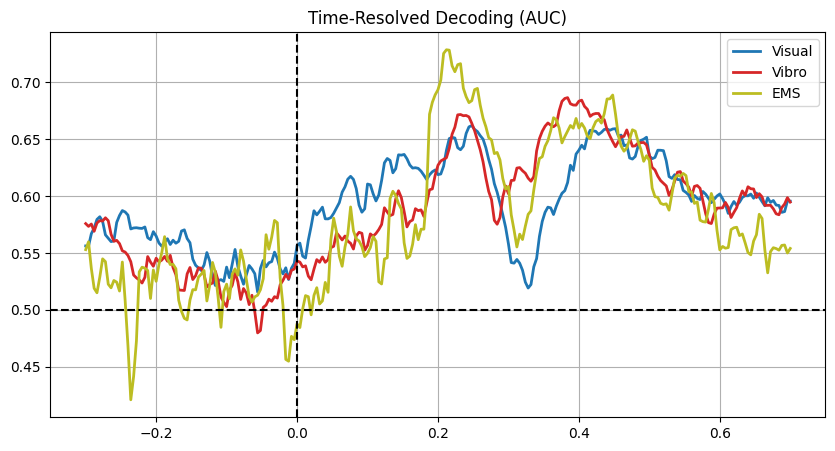

In [10]:
# Plot grand average
all_mean_scores = {session: [] for session in ["Visual", "Vibro", "EMS"]}
for session in ["Visual", "Vibro", "EMS"]:
    subjects = scores_all.keys()
    mean_scores = []
    for subject in subjects:
        if session in scores_all[subject]:
            mean_scores.append(scores_all[subject][session])
    
    if mean_scores:
        all_mean_scores[session] = np.mean(mean_scores, axis=0).copy()


colors = {"Visual": "C0",
        "Vibro": "C3",
        "EMS": "C8"}
plt.figure(figsize=(10, 5))
for session in ["Visual", "Vibro", "EMS"]:
    if session in all_mean_scores:
        plt.plot(np.linspace(-0.3, 0.7, len(all_mean_scores[session])), all_mean_scores[session], color=colors[session], label=session, linewidth=2)
plt.axhline(0.5, color="k", linestyle="--")
plt.axvline(0.0, color="k", linestyle="--")
plt.title("Time-Resolved Decoding (AUC)")
plt.legend()
plt.grid()
plt.savefig("time_resolved_decoding.pdf", format="pdf")
plt.show()